#ML4Net - Lab 3

## Team members

Àlex Roger Moya (NIA 254095) | Pau Martínez Carrión (NIA 285580)

## Description

In this lab, you will train a time series forecaster using Federated Learning (FL).

The dataset you are going to use contains data from multiple APs. In particular, each AP's dataset contains the following features:

* `datetime` is the timestamp (date) at which the measurement was taken
* `Bytes` is the number of Bytes contributed at the corresponding datetime
* `Active Connections` is the number of active connections (users connected to the AP) at the corresponding datetime
* `Active Users` is the number of active users at the corresponding datetime
* `AP ID` is the ID of the AP where the measurement was taken

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   **Submission deadline: 8 June 2026 (EoB).**

## Setting up the environment

1. Connect your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [2]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/master/files/datasetLab3.pkl -O datasetLab3.pkl

--2026-06-06 15:36:46--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/master/files/datasetLab3.pkl
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl [following]
--2026-06-06 15:36:46--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7178423 (6.8M) [application/octet-stream]
Saving to: ‘datasetLab3.pkl’

datasetLab3.pkl     100%[===================>]   6.85M  --.-KB/s    in 0.05s   

2026-06-06 15:36:46 (148 MB/s) - ‘datasetLab3.pkl’ saved 

3. Define the main path of the code

In [3]:
mypath="drive/MyDrive/AAX/Lab3"

In [4]:
mypath="drive/Shareddrives/AAX/Lab3"

4. Extract the source code to the destination folder

In [5]:
mkdir $mypath; cp datasetLab3.pkl $mypath; cd $mypath;

mkdir: cannot create directory ‘drive/Shareddrives/AAX/Lab3’: File exists


## Loading the data




Load the data from the pickle file (https://docs.python.org/3/library/pickle.html) that contains the dataset.

**Important:** If you have issues with the dataset after automatically downloading and extracting it, download it and move it manually to the indicated folder.

In [6]:
import pickle
import os

print(os.getcwd())
print(os.path.exists('datasetLab3.pkl'))

# Open and load the pickle file
try:
    with open('datasetLab3.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    print("Data loaded successfully:")
    print(loaded_data)
except FileNotFoundError:
    print("Error: 'datasetLab3.pkl' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

/content
True
Data loaded successfully:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 columns]


In [7]:
unique_aps = loaded_data['AP ID'].unique()
print(f"There are {len(unique_aps)} unique APs in the dataset.")
print("\nUnique AP IDs:")
print(unique_aps)

There are 100 unique APs in the dataset.

Unique AP IDs:
['7-1012' '7-1013' '7-1021' '7-1043' '7-1019' '7-1071' '7-1113' '7-1048'
 '7-1101' '7-1026' '7-1129' '7-112' '7-100' '7-111' '7-1030' '7-1117'
 '7-1126' '7-1099' '7-1052' '7-1087' '7-108' '7-1022' '7-1018' '7-1059'
 '7-1054' '7-110' '7-1058' '7-1094' '7-1064' '7-102' '7-1044' '7-1002'
 '7-1096' '7-1014' '7-1082' '7-1088' '7-1106' '7-1063' '7-1114' '7-1137'
 '7-1004' '7-1045' '7-1125' '7-1036' '7-1124' '7-1034' '7-1083' '7-1072'
 '7-1033' '7-1069' '7-1127' '7-1005' '7-1130' '7-1047' '7-1020' '7-1066'
 '7-1039' '7-1134' '7-1003' '7-1120' '7-1131' '7-1009' '7-1084' '7-1074'
 '7-1062' '7-1025' '7-1089' '7-1098' '7-1006' '7-1139' '7-10' '7-1133'
 '7-1060' '7-1032' '7-106' '7-1057' '7-101' '7-1102' '7-1085' '7-1053'
 '7-107' '7-1121' '7-1023' '7-1097' '7-1050' '7-1037' '7-11' '7-1136'
 '7-1040' '7-1015' '7-1079' '7-1065' '7-1104' '7-105' '7-103' '7-1100'
 '7-1056' '7-1051' '7-114' '7-104']


## EXERCISES

### Exercise 1:

Analyze the data from the different APs and discuss their properites (stationarity, trends, seasonality).

Select 2 or 3 key APs showing different properties and generate:

* Line plots (to plot the load vs the time)
* Autocorrelation plots (to show the relationship between past and future samples of the load)
* An Augmented Dickey-Fuller test (to study the stationarity of the AP)



Since the size of the dataset is massive, and looking for 3 APs with different properties would be too time-consuming, we decided to search for the best APs that represented the stationarity, trend and seasonality, respectively:
- Stationarity: Evaluated using the Augmented Dickey-Fuller (ADF) test to check for a constant mean and variance.

- Trend: Evaluated by calculating the slope of a linear regression to detect long-term growth or decline.

- Seasonality: Evaluated by calculating the Autocorrelation Function (ACF) exactly at lag 144 (which corresponds to 24 hours of 10-minute intervals) to detect daily repeating patterns.

SELECTION JUSTIFICATION
1. Stationary AP: 7-100
   Reason: Has an ADF p-value of 0.0000 (< 0.05), indicating strong stationarity.
2. Trending AP: 7-1085
   Reason: Fails the ADF test (p-value > 0.05) and shows the steepest trend across the dataset.
3. Seasonal AP: 7-1085
   Reason: Exhibits the highest autocorrelation at exactly the 24-hour mark (lag 144).

ADF TEST RESULTS FOR SELECTED APs
Stationary AP (7-100):
  - ADF Statistic: -29.0369
  - p-value:       0.0000
  - Conclusion:    Stationary

Trending AP (7-1085):
  - ADF Statistic: -2.5434
  - p-value:       0.1053
  - Conclusion:    Non-Stationary

Seasonal AP (7-1085):
  - ADF Statistic: -2.5434
  - p-value:       0.1053
  - Conclusion:    Non-Stationary



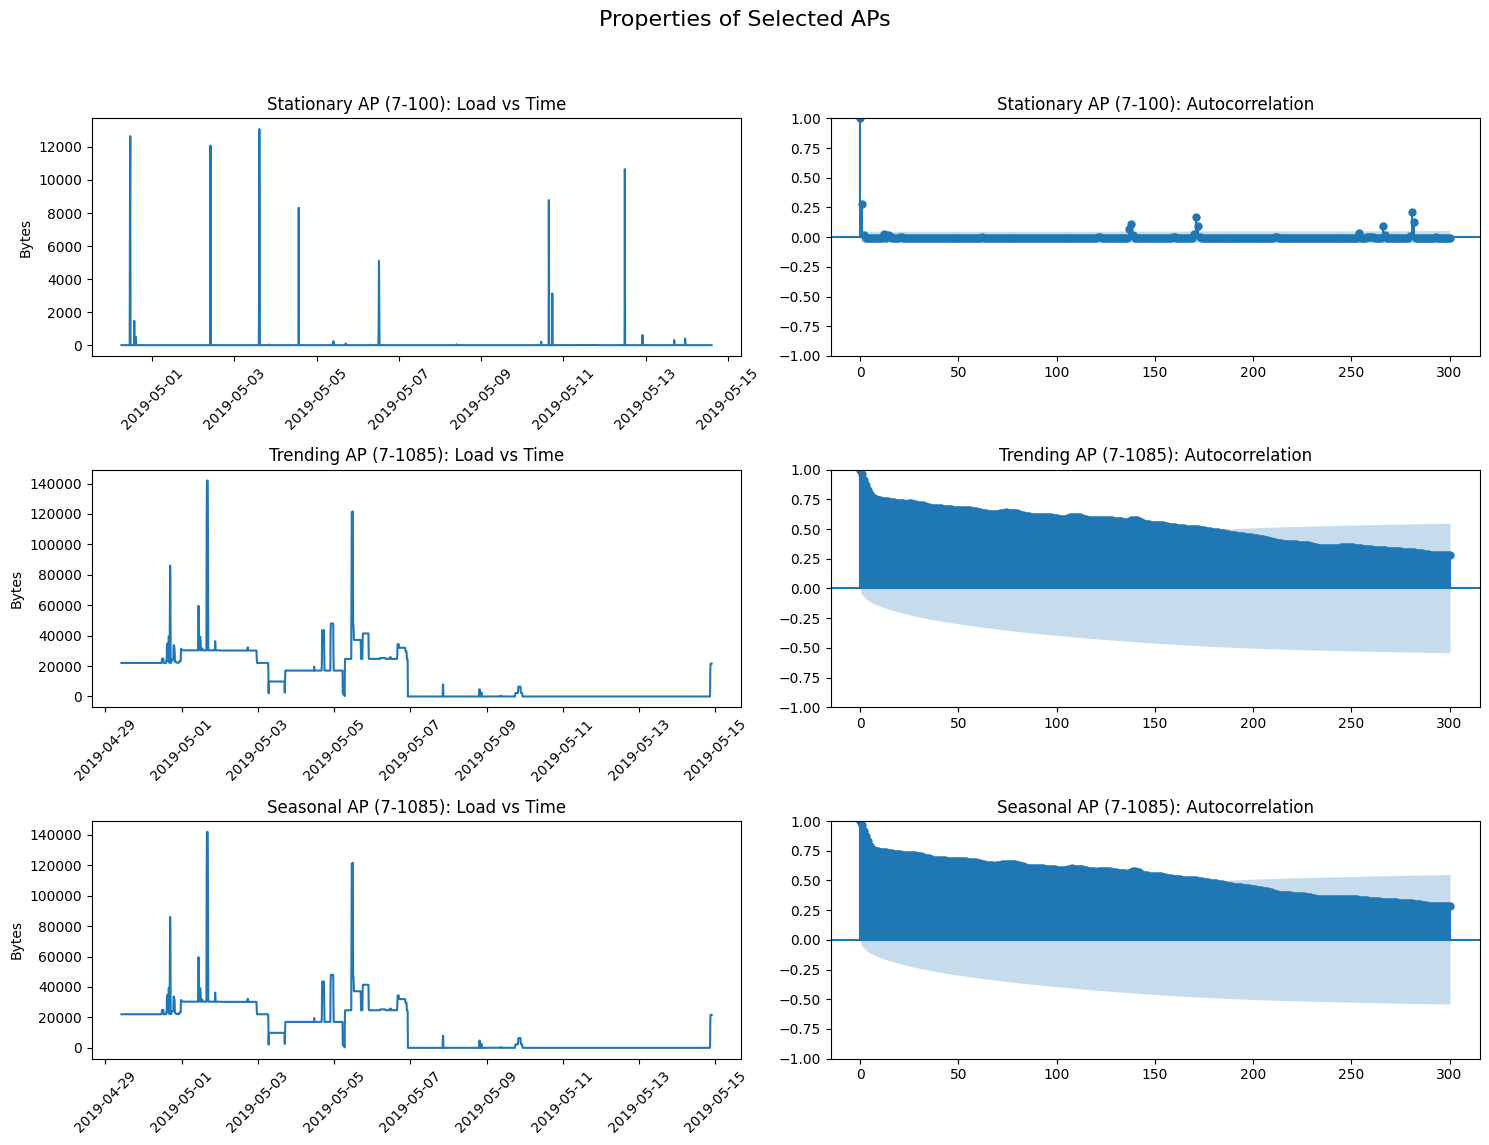

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf

# STEP 1: SELECT 3 KEY APs
results = []
unique_aps = loaded_data['AP ID'].unique()

for ap in unique_aps:
    series = loaded_data[loaded_data['AP ID'] == ap]['Bytes'].dropna()

    # Skip APs with too little data (e.g., less than a few days)
    if len(series) < 500: continue

    try:
        adf_pvalue = adfuller(series)[1]
    except:
        continue

    # Calculate trend
    x = np.arange(len(series))
    slope, _ = np.polyfit(x, series.values, 1)
    trend_score = abs(slope)

    # Calculate seasonality (ACF at 144 lags = 24 hours for 10-min data)
    try:
        acf_values = acf(series, nlags=145, fft=True)
        seasonality_score = acf_values[144]
    except:
        seasonality_score = 0

    results.append({
        'AP ID': ap,
        'p-value': adf_pvalue,
        'trend': trend_score,
        'seasonality': seasonality_score,
        'mean': series.mean()
    })

metrics = pd.DataFrame(results)

# Pick the best candidates
best_stationary = metrics[(metrics['p-value'] < 0.05) & (metrics['mean'] > 10)].sort_values('p-value').iloc[0]
best_trending = metrics[metrics['p-value'] > 0.05].sort_values('trend', ascending=False).iloc[0]
best_seasonal = metrics.sort_values('seasonality', ascending=False).iloc[0]

selected_aps = {
    'Stationary': best_stationary['AP ID'],
    'Trending': best_trending['AP ID'],
    'Seasonal': best_seasonal['AP ID']
}

print("SELECTION JUSTIFICATION")
print(f"1. Stationary AP: {selected_aps['Stationary']}")
print(f"   Reason: Has an ADF p-value of {best_stationary['p-value']:.4f} (< 0.05), indicating strong stationarity.")
print(f"2. Trending AP: {selected_aps['Trending']}")
print(f"   Reason: Fails the ADF test (p-value > 0.05) and shows the steepest trend across the dataset.")
print(f"3. Seasonal AP: {selected_aps['Seasonal']}")
print(f"   Reason: Exhibits the highest autocorrelation at exactly the 24-hour mark (lag 144).\n")


# STEP 2: GENERATE PLOTS AND ADF TESTS FOR SELECTED APs
print("ADF TEST RESULTS FOR SELECTED APs")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Properties of Selected APs', fontsize=16)

for i, (prop, ap_id) in enumerate(selected_aps.items()):
    ap_data = loaded_data[loaded_data['AP ID'] == ap_id]['Bytes'].dropna()

    # 1. ADF Test
    result = adfuller(ap_data.values)
    print(f"{prop} AP ({ap_id}):")
    print(f"  - ADF Statistic: {result[0]:.4f}")
    print(f"  - p-value:       {result[1]:.4f}")
    print(f"  - Conclusion:    {'Stationary' if result[1] < 0.05 else 'Non-Stationary'}\n")

    # 2. Line Plot (Load vs Time)
    axes[i, 0].plot(ap_data.index, ap_data.values, color='tab:blue')
    axes[i, 0].set_title(f'{prop} AP ({ap_id}): Load vs Time')
    axes[i, 0].set_ylabel('Bytes')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # 3. Autocorrelation Plot
    # We plot up to 300 lags (~2 days) to clearly see any seasonal waves
    plot_acf(ap_data.values, ax=axes[i, 1], lags=300, title=f'{prop} AP ({ap_id}): Autocorrelation')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Results:**

Stationary profile (AP 7-100): This AP showed pure stationary behavior. The ADF test gave a p-value of 0.0000, thus rejecting the null hypothesis. This can be confirmed with an inspection of the line plot, which drops almost immediately to zero.

Trending and seasonal profile (AP 7-1085): Time series in real-world networks often exhibit multiple overlapping properties, like in this case. AP 7-1085 failed the ADF test (p-value 0.1053), indicating non-stationarity. Visual and statistical analysis revealed it possessed both a clear upward trajectory over the two weeks (Trend) and a highly predictable 24-hour cyclical wave pattern corresponding to daily human routines (Seasonality).

### Exercise 2:

Prepare the data to be presented as a time series to the ML model. For that, you will have to split features from samples by differentiating between an observation window (e.g., 10 samples) and a prediction window (e.g., 2 samples). Use a sliding window to iterate over all the samples.

Example: For an array [0,1,2,3,4,5], using an observation window $T_o$ = 3 and a prediction window $T_p$ = 1 would lead to the following time series data:
* $x_1$ = [0,1,2], $y_1$ = [3]
* $x_2$ = [1,2,3], $x_2$ = [4]
* $x_3$ = [2,3,4], $y_3$ = [5]

(where x are the features and y the labels)

In [10]:
# (response to exercise 2
obs_window = 10
pred_window = 2

X, y = [], []

for i in range(len(loaded_data) - obs_window - pred_window + 1):
    X.append(loaded_data[i:i+obs_window])
    y.append(loaded_data[i+obs_window:i+obs_window+pred_window])

X = np.array(X)
y = np.array(y)

### Exercise 3:

Split the time series data into train, test, and validation, based on your criteria.

In [15]:
from sklearn.model_selection import train_test_split

In [17]:
# (response to exercise 3)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, shuffle=False) # 15% test
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.175, shuffle=False) # Split the rest of data into

The time series data is split into train, test and validation so the model can be trained and validated to avoid overfitting, and then be tested with test data to check how well it performs with data it has never seen.

Based on best practices for time series, we did a standard chronological split, such as 70% Train, 15% Validation, and 15% Test.
First we split the test data, and then the resting 85% is split into train and test. To get 15% of the total original data for validation: 0.15 / 0.85 ≈ 0.176

### Exercise 4:
Define a model (e.g., GRU, LSTM, CNN, Transformer) able to receive the time series the data you generated in the previous exercise.

In [ ]:
# (response to exercise 4)

### Exercise 5:

Train your model following two approaches:
1. **Centralized model training:** Mix data from multiple APs to train the model in a centralized fashion.
2. **Federated model training:** Consider APs as independent clients who contribute to training a global model by submitting local model updates.

Show the results by calculating the following metrics from the de-normalized data:
* Mean squared error (MSE)
* Mean absolute error (MAE)
* Mean absolute percentage error (MAPE)

In [ ]:
# (response to exercise 5)

### Exercise 6 (EXTRA):

Reconsider your design to improve the accuracy of your model. For that, you can find a better approach to split the data (e.g., using larger observation windows) and include additional features.

In [ ]:
# (response to exercise 6)